# Heart Disease Dataset — Exploratory Data Analysis & Preprocessing Pipeline

**Dataset:** Cleveland Heart Disease (UCI ML Repository)  
**Objective:** Understand the data structure, uncover clinical insights, and build a robust sklearn preprocessing pipeline ready for ML modeling.

---

> **Notebook Structure**
> 1. Environment Setup  
> 2. Data Loading & First Look  
> 3. Data Quality Check  
> 4. Target Distribution  
> 5. Univariate Analysis  
> 6. Correlation & Multivariate Analysis  
> 7. Outlier Detection  
> 8. Feature Engineering  
> 9. Preprocessing Pipeline  
> 10. End-to-End ML Pipeline Demo  
> 11. Summary

## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE  = {'No Disease': '#4C72B0', 'Disease': '#DD8452'}
RED      = '#DD8452'
BLUE     = '#4C72B0'
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

print("✅ Environment ready — all libraries imported.")


✅ Environment ready — all libraries imported.


## 2. Data Loading & First Look

The Cleveland Heart Disease dataset contains **303 patients** and **13 clinical features** with a binary target indicating the presence of heart disease.


In [2]:
COLUMN_METADATA = {
    'age'     : 'Age (years)',
    'sex'     : 'Sex (1=Male, 0=Female)',
    'cp'      : 'Chest Pain Type (0-3)',
    'trestbps': 'Resting Blood Pressure (mmHg)',
    'chol'    : 'Serum Cholesterol (mg/dl)',
    'fbs'     : 'Fasting Blood Sugar > 120 mg/dl (1=True)',
    'restecg' : 'Resting ECG Results (0-2)',
    'thalach' : 'Max Heart Rate Achieved',
    'exang'   : 'Exercise-Induced Angina (1=Yes)',
    'oldpeak' : 'ST Depression (exercise vs rest)',
    'slope'   : 'Slope of Peak Exercise ST Segment (0-2)',
    'ca'      : '# Major Vessels Colored by Fluoroscopy (0-3)',
    'thal'    : 'Thalassemia (1=Normal, 2=Fixed Defect, 3=Reversible Defect)',
    'target'  : 'Heart Disease Present (1=Yes, 0=No)',
}

DATA_PATH = r'..\data\Heart_disease.csv'
df = pd.read_csv(DATA_PATH)

# Friendly label for plotting
df['diagnosis'] = df['target'].map({0: 'No Disease', 1: 'Disease'})

print(f"Dataset shape : {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)


Dataset shape : 303 rows × 15 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,diagnosis
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0,No Disease
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1,Disease
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1,Disease
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0,No Disease
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0,No Disease
5,56,1,1,120,236,0,0,178,0,0.8,0,0,1,0,No Disease
6,62,0,3,140,268,0,2,160,0,3.6,2,2,1,1,Disease
7,57,0,3,120,354,0,0,163,1,0.6,0,0,1,0,No Disease
8,63,1,3,130,254,0,2,147,0,1.4,1,1,3,1,Disease
9,53,1,3,140,203,1,2,155,1,3.1,2,0,3,1,Disease


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   cp         303 non-null    int64  
 3   trestbps   303 non-null    int64  
 4   chol       303 non-null    int64  
 5   fbs        303 non-null    int64  
 6   restecg    303 non-null    int64  
 7   thalach    303 non-null    int64  
 8   exang      303 non-null    int64  
 9   oldpeak    303 non-null    float64
 10  slope      303 non-null    int64  
 11  ca         303 non-null    int64  
 12  thal       303 non-null    int64  
 13  target     303 non-null    int64  
 14  diagnosis  303 non-null    str    
dtypes: float64(1), int64(13), str(1)
memory usage: 35.6 KB


In [4]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

,count,mean,std,min,25%,50%,75%,max
age,303.000000,54.438944,9.038662,29.000000,48.000000,56.000000,61.000000,77.000000
sex,303.000000,0.679868,0.467299,0.000000,0.000000,1.000000,1.000000,1.000000
cp,303.000000,2.158416,0.960126,0.000000,2.000000,2.000000,3.000000,3.000000
trestbps,303.000000,131.689769,17.599748,94.000000,120.000000,130.000000,140.000000,200.000000
chol,303.000000,246.693069,51.776918,126.000000,211.000000,241.000000,275.000000,564.000000
fbs,303.000000,0.148515,0.356198,0.000000,0.000000,0.000000,0.000000,1.000000
restecg,303.000000,0.990099,0.994971,0.000000,0.000000,1.000000,2.000000,2.000000
thalach,303.000000,149.607261,22.875003,71.000000,133.500000,153.000000,166.000000,202.000000
exang,303.000000,0.326733,0.469794,0.000000,0.000000,0.000000,1.000000,1.000000
oldpeak,303.000000,1.039604,1.161075,0.000000,0.000000,0.800000,1.600000,6.200000


## 3. Data Quality Check

In [5]:
# ── Missing values ──────────────────────────────────────────────────────────
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)

quality = pd.DataFrame({
    'Missing Count': miss,
    'Missing %'    : miss_pct,
    'Dtype'        : df.dtypes,
    'Unique Values': df.nunique(),
    'Min'          : df.min(),
    'Max'          : df.max(),
})
quality.style.background_gradient(cmap='Oranges', subset=['Missing %'])


,Missing Count,Missing %,Dtype,Unique Values,Min,Max
age,0,0.000000,int64,41,29,77
sex,0,0.000000,int64,2,0,1
cp,0,0.000000,int64,4,0,3
trestbps,0,0.000000,int64,50,94,200
chol,0,0.000000,int64,152,126,564
fbs,0,0.000000,int64,2,0,1
restecg,0,0.000000,int64,3,0,2
thalach,0,0.000000,int64,91,71,202
exang,0,0.000000,int64,2,0,1
oldpeak,0,0.000000,float64,40,0.000000,6.200000


> **Data Quality Verdict:** No missing values detected. All 303 records are complete. But, we still apply a robust imputer in the pipeline as a defensive measure for production use.

## 4. Target Distribution

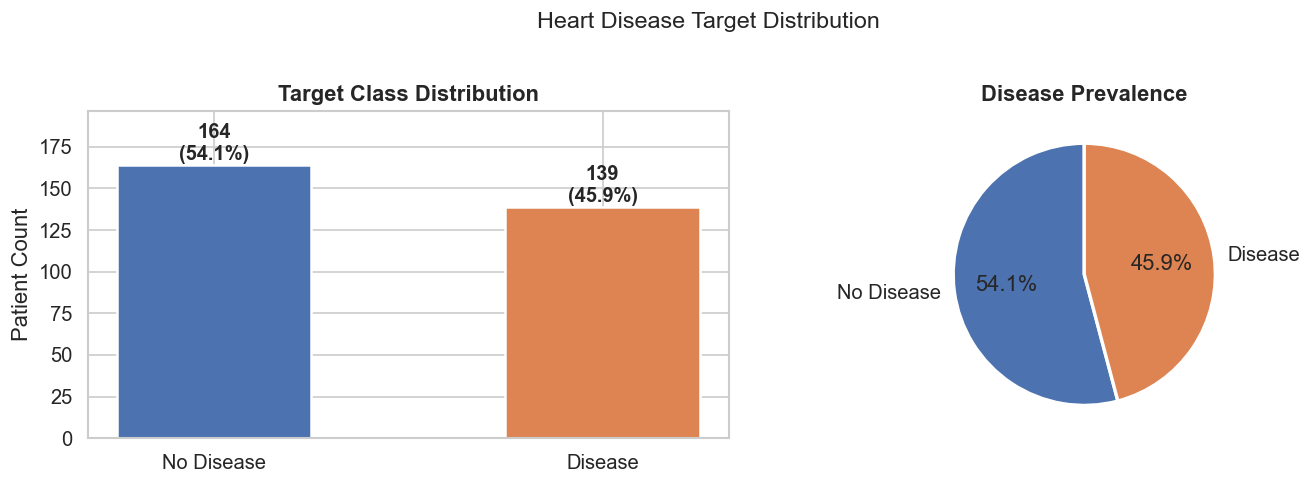


Class ratio (No Disease : Disease) = 164 : 139  →  1.18:1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values, color=[BLUE, RED], edgecolor='white', linewidth=1.5, width=0.5)
for i, (label, v) in enumerate(counts.items()):
    axes[0].text(i, v + 3, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Patient Count')
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[BLUE, RED], startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Disease Prevalence')

plt.suptitle('Heart Disease Target Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

nd, d = counts['No Disease'], counts['Disease']
print(f"\nClass ratio (No Disease : Disease) = {nd} : {d}  →  {nd/d:.2f}:1")


> The dataset is is **close enough to balanced** that standard accuracy metrics are acceptable, though AUROC and F1 remain preferred for clinical use-cases. No resampling (SMOTE/undersampling) is strictly required here.

## 5. Univariate Analysis

### 5.1 Continuous Features


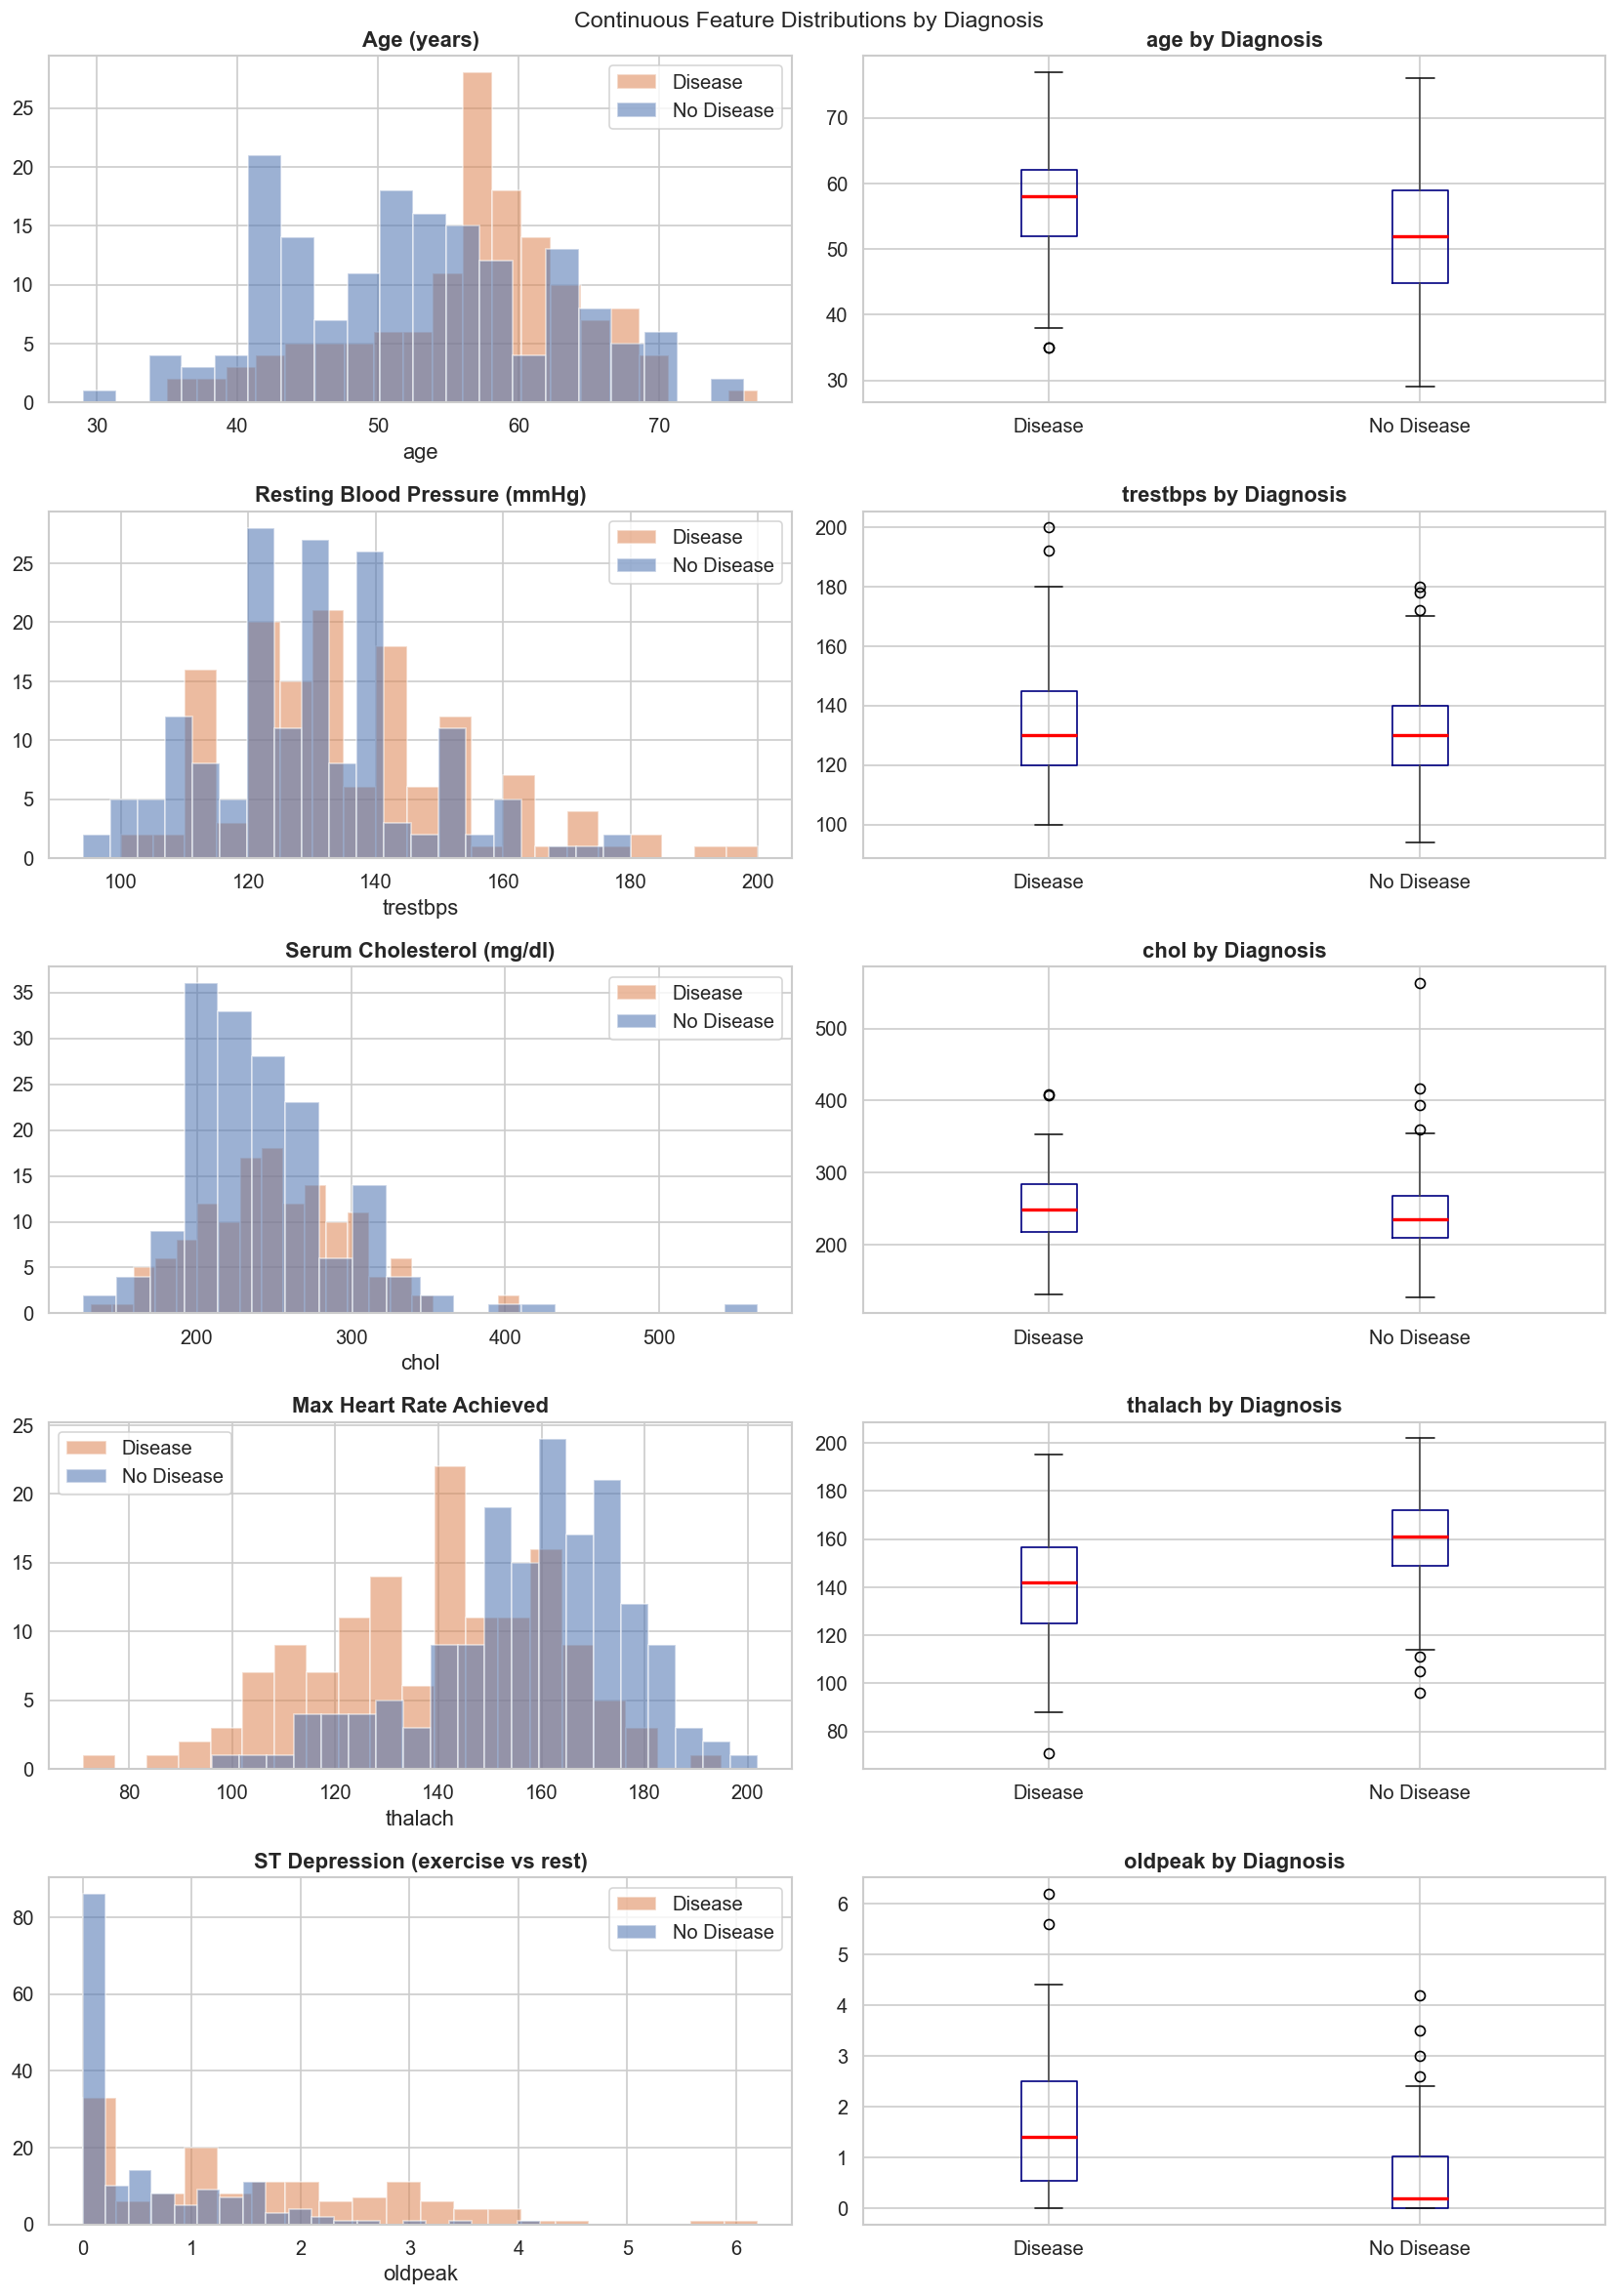

In [7]:
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(len(continuous), 2, figsize=(14, 4 * len(continuous)))

for i, col in enumerate(continuous):
    # KDE by class
    for label, grp in df.groupby('diagnosis'):
        axes[i, 0].hist(grp[col], bins=20, alpha=0.55,
                        color=PALETTE[label], label=label, edgecolor='white')
    axes[i, 0].set_title(f'{COLUMN_METADATA[col]}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].legend()

    # Boxplot
    df.boxplot(column=col, by='diagnosis', ax=axes[i, 1],
               boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{col} by Diagnosis')
    axes[i, 1].set_xlabel('')

plt.suptitle('Continuous Feature Distributions by Diagnosis', fontsize=14)
plt.tight_layout()
plt.show()

**Key Insights from Feature Distributions: -**

- **Age**
  - Disease patients are slightly older
  - Overlap exists → weak/moderate predictor
  - Distribution: approximately **normal (slight right skew)**

- **Resting Blood Pressure (trestbps)**
  - Very similar distributions
  - Weak feature
  - Distribution: **roughly normal (slight right skew + outliers)**

- **Cholesterol (chol)**
  - Heavy overlap + many outliers
  - Not a strong standalone predictor
  - Distribution: **right-skewed (long tail + many outliers)**

- **Max Heart Rate (thalach)**
  - Higher in No Disease group
  - Good separation → strong feature
  - Distribution: **slightly left-skewed (especially No Disease)**

- **ST Depression (oldpeak)**
  - Higher in Disease group
  - Clear separation → very strong feature
  - Distribution: **highly right-skewed (many near 0, long tail)**


**Summary**

- **Strong features:** `oldpeak`, `thalach`  
- **Moderate:** `age`  
- **Weak:** `trestbps`, `chol`  

- Most features are **not perfectly normal** → scaling like **RobustScaler / StandardScaler** is appropriate  
- Presence of **skewness + outliers** (especially `chol`, `oldpeak`) impacts modeling  

No single feature is enough → model must combine them

### 5.2 Categorical Features

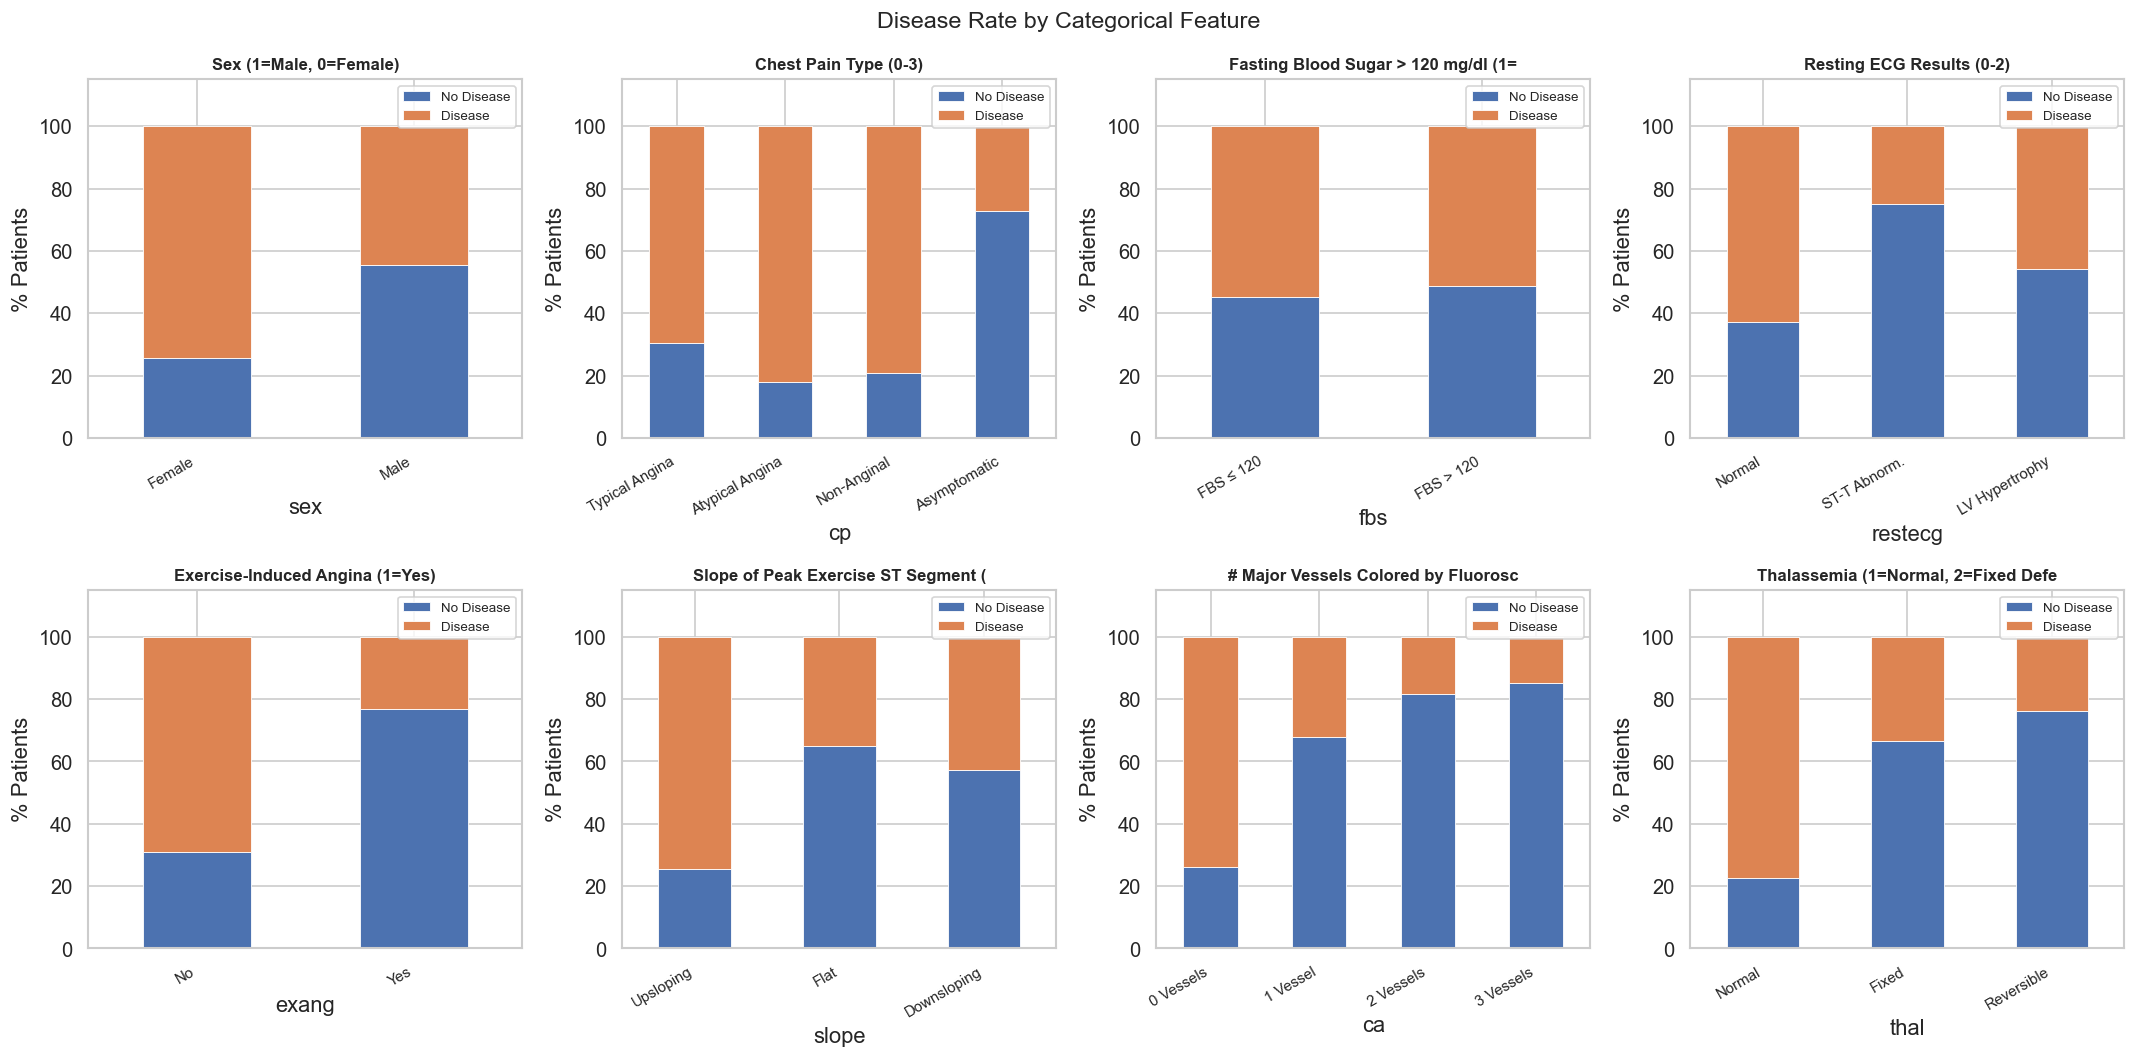

In [8]:
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

cat_labels = {
    'sex'    : {0: 'Female', 1: 'Male'},
    'cp'     : {0: 'Typical Angina', 1: 'Atypical Angina', 2: 'Non-Anginal', 3: 'Asymptomatic'},
    'fbs'    : {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnorm.', 2: 'LV Hypertrophy'},
    'exang'  : {0: 'No', 1: 'Yes'},
    'slope'  : {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'ca'     : {0: '0 Vessels', 1: '1 Vessel', 2: '2 Vessels', 3: '3 Vessels'},
    'thal'   : {1: 'Normal', 2: 'Fixed', 3: 'Reversible'},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(categorical):
    ct = df.groupby([col, 'diagnosis']).size().unstack(fill_value=0)
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    pct.plot(kind='bar', stacked=True, ax=axes[i],
             color=[BLUE, RED], edgecolor='white', linewidth=0.5)
    
    if col in cat_labels:
        axes[i].set_xticklabels(
            [cat_labels[col].get(int(t.get_text()), t.get_text()) for t in axes[i].get_xticklabels()],
            rotation=30, ha='right', fontsize=9)
    else:
        axes[i].tick_params(axis='x', rotation=30)
    
    axes[i].set_title(COLUMN_METADATA[col][:35], fontsize=10)
    axes[i].set_ylabel('% Patients')
    axes[i].set_ylim(0, 115)
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)

plt.suptitle('Disease Rate by Categorical Feature', fontsize=14)
plt.tight_layout()
plt.show()


**Key Insights from Categorical Features: -**

- **Sex**
  - Females → higher disease rate  
  - Males → more balanced  
  Moderate signal

- **Chest Pain Type (cp)**
  - Asymptomatic → mostly No Disease  
  - Other types → higher Disease rates  
  Strong feature

- **Fasting Blood Sugar (fbs)**
  - Very similar proportions  
  Weak feature

- **Resting ECG (restecg)**
  - ST-T abnormality → more No Disease  
  - Others mixed  
  Weak / unclear signal

- **Exercise-Induced Angina (exang)**
  - No angina → high Disease  
  - Yes → mostly No Disease  
  Strong feature (inverse relation)

- **Slope**
  - Upsloping → high Disease  
  - Flat → more No Disease  
  Moderate signal

- **# Major Vessels (ca)**
  - 0 vessels → high Disease  
  - More vessels → more No Disease  
  Very strong feature

- **Thalassemia (thal)**
  - Normal → high Disease  
  - Fixed/Reversible → more No Disease  
  Strong feature

**Summary**

- **Strong features:** `cp`, `exang`, `ca`, `thal`  
- **Moderate:** `sex`, `slope`  
- **Weak:** `fbs`, `restecg`  

Categorical features show clearer separation than continuous ones

## 6. Correlation & Multivariate Analysis

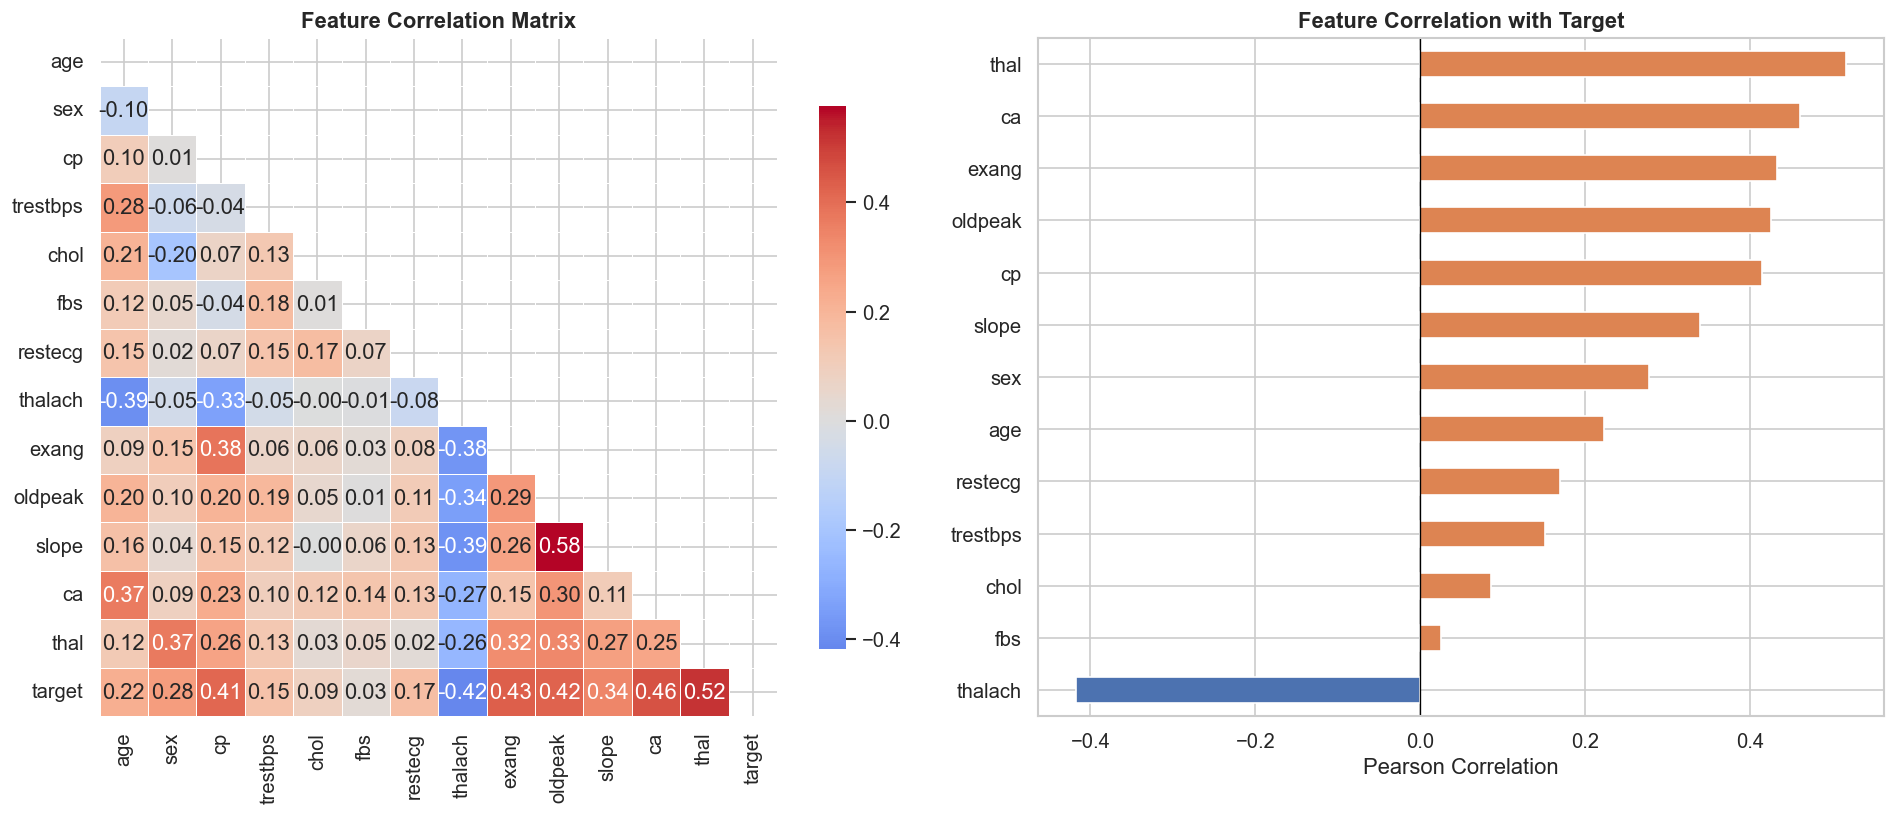

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full correlation heatmap
corr = df.drop(columns='diagnosis').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix')

# Correlation with target (sorted)
target_corr = corr['target'].drop('target').sort_values()
colors = [RED if v > 0 else BLUE for v in target_corr]
target_corr.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Target')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()


> **Correlation Insights: -**
> - **thalach** (max heart rate) has the strongest *negative* correlation with target — lower max HR → higher disease risk.
> - **oldpeak**, **ca**, and **exang** are the top *positive* correlators — all clinically meaningful.
> - **cp** (chest pain type) encodes important information despite being ordinal — higher values associate with disease.
> - Feature multicollinearity is low overall, which is favorable for many ML algorithms.


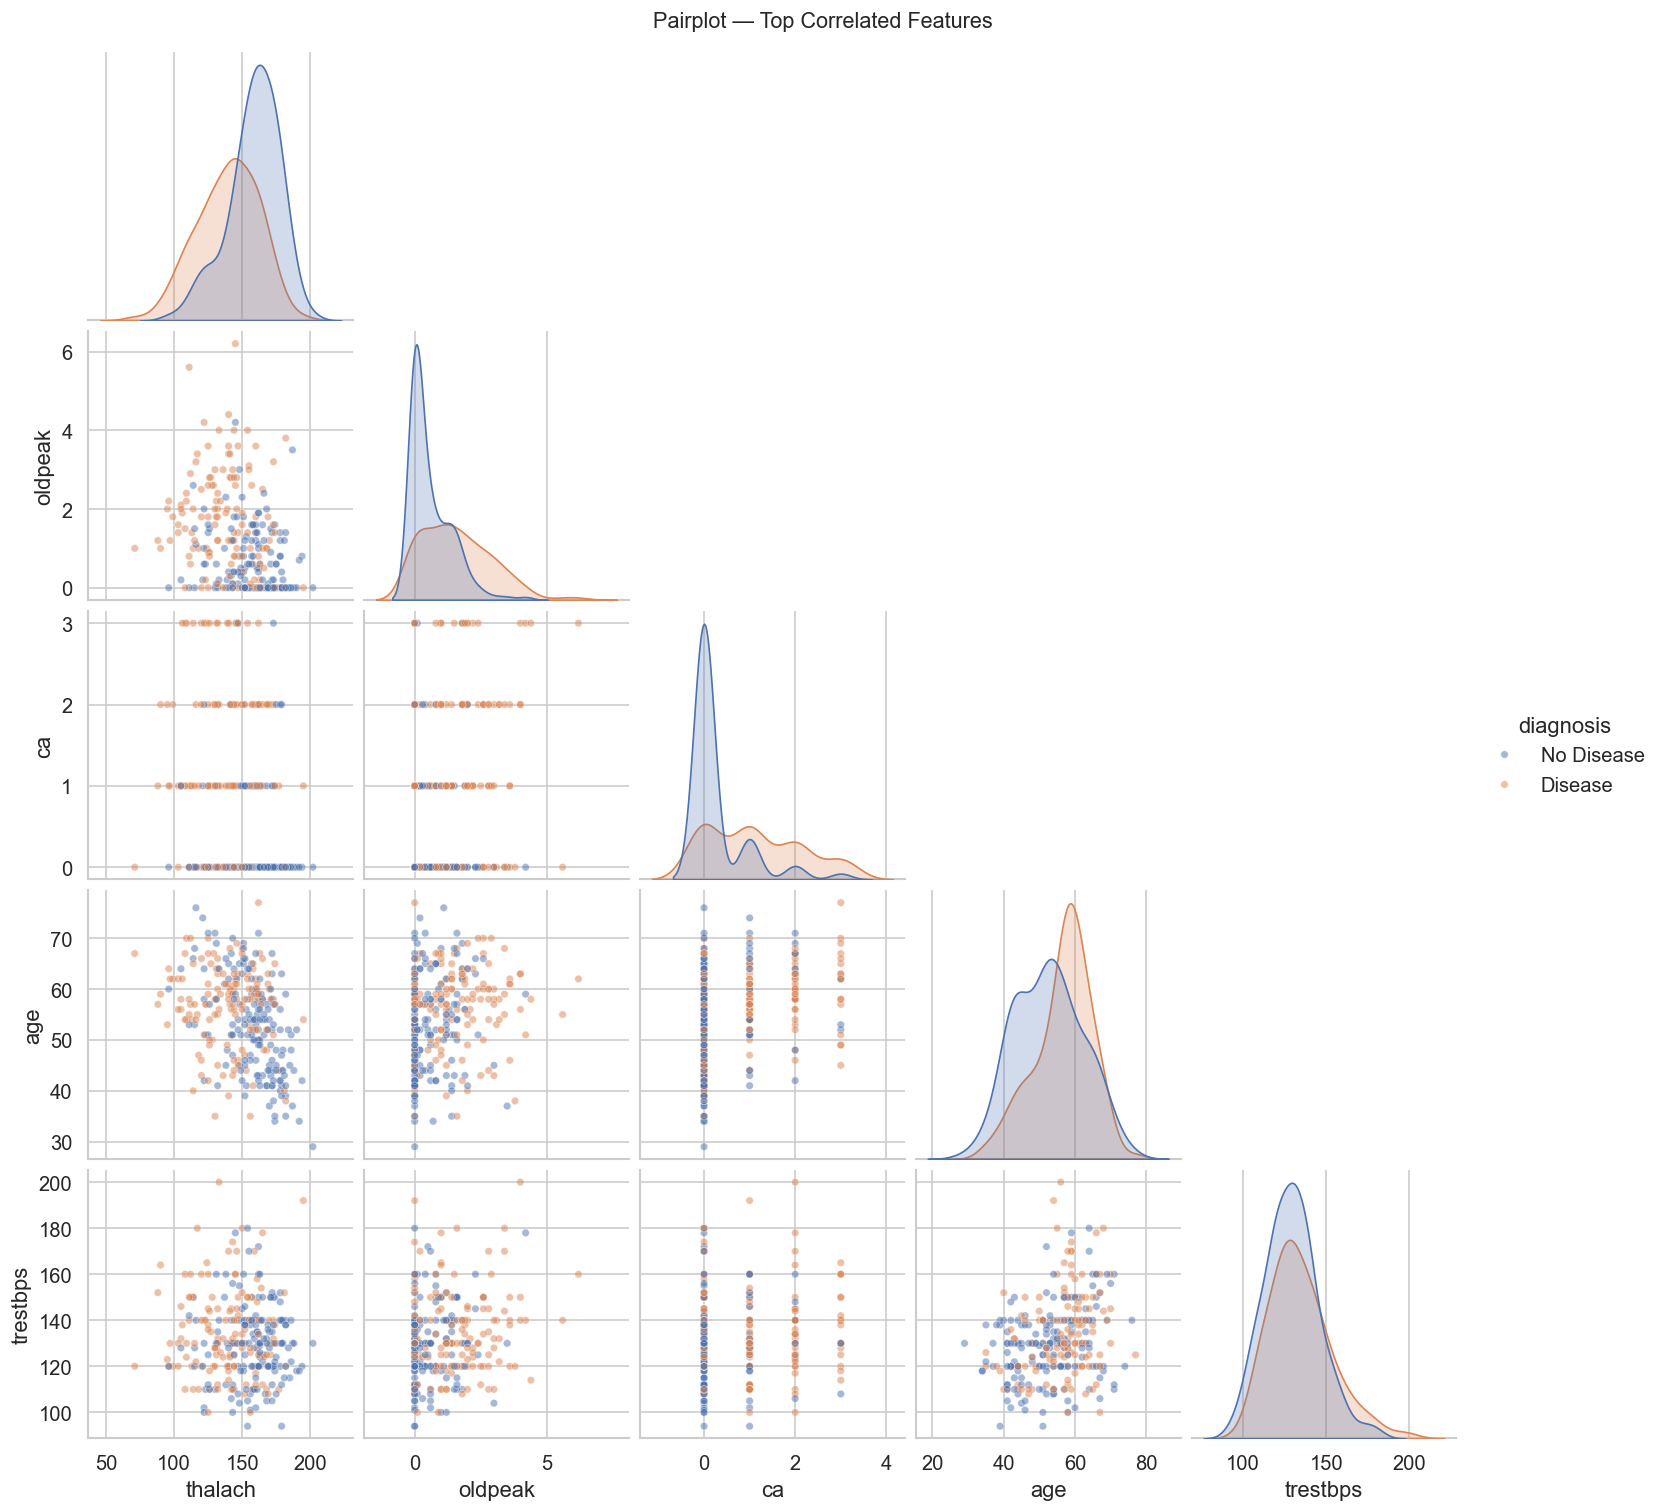

In [10]:
# Pairplot for top features
top_features = ['thalach', 'oldpeak', 'ca', 'age', 'trestbps', 'diagnosis']
g = sns.pairplot(df[top_features], hue='diagnosis', palette=PALETTE,
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20},
                 corner=True)
g.figure.suptitle('Pairplot — Top Correlated Features', y=1.01, fontsize=13)
plt.show()


> **Pairplot Insights: -**
> - **oldpeak** and **ca** show clear separation → strong predictors  
> - **thalach** is inversely related to disease → good feature  
> - **age** has moderate overlap
> - **trestbps** shows heavy overlap → weak feature  
> - Low multicollinearity overall → features are complementary  

## 7. Outlier Detection

In [11]:
from scipy import stats

print("=== IQR-based Outlier Count per Continuous Feature ===\n")
outlier_summary = []
for col in continuous:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append({'Feature': col, 'Lower Fence': round(lo,2), 'Upper Fence': round(hi,2), 'Outliers': n_out, 'Outlier %': round(n_out/len(df)*100,2)})

pd.DataFrame(outlier_summary).set_index('Feature').style.background_gradient(cmap='Reds', subset=['Outlier %'])


=== IQR-based Outlier Count per Continuous Feature ===



,Lower Fence,Upper Fence,Outliers,Outlier %
Feature,,,,
age,28.500000,80.500000,0,0.000000
trestbps,90.000000,170.000000,9,2.970000
chol,115.000000,371.000000,5,1.650000
thalach,84.750000,214.750000,1,0.330000
oldpeak,-2.400000,4.000000,5,1.650000


> **Outlier Strategy:** Cholesterol has the most outliers (very high values possible in reality). We will use **RobustScaler** for continuous features to dampen the influence of outliers rather than removing records — preserving the clinical population's representativeness.


## 8. Feature Engineering

In [12]:
df_fe = df.copy()

# Hypertension flag
df_fe['hypertension'] = (df_fe['trestbps'] >= 140).astype(int)

# High cholesterol flag (AHA threshold)
df_fe['high_chol'] = (df_fe['chol'] >= 240).astype(int)

# Heart rate reserve proxy: thalach relative to age-predicted max (220 - age)
df_fe['hr_reserve_pct'] = df_fe['thalach'] / (220 - df_fe['age'])

print("New features added:")
print(df_fe[['age','trestbps','hypertension','chol','high_chol','thalach','hr_reserve_pct']].head(8))


New features added:
   age  trestbps  hypertension  chol  high_chol  thalach  hr_reserve_pct
0   63       145             1   233          0      150        0.955414
1   67       160             1   286          1      108        0.705882
2   67       120             0   229          0      129        0.843137
3   37       130             0   250          1      187        1.021858
4   41       130             0   204          0      172        0.960894
5   56       120             0   236          0      178        1.085366
6   62       140             1   268          1      160        1.012658
7   57       120             0   354          1      163        1.000000


> **Feature Engineering Notes:**
> - **Hypertension flag** uses the standard clinical threshold (≥140 mmHg).
> - **High cholesterol** highlights critical risk levels (≥240 mg/dL) instead of relying only on raw cholesterol values.
> - **Heart Rate Reserve %** normalizes thalach against age-predicted max HR — a richer metric than raw thalach.


## 9. Preprocessing Pipeline

We build a clean, modular **scikit-learn Pipeline** with:
- Separate transformers for numerical and categorical features
- Imputation (defensive, for production robustness)
- Scaling: **StandardScaler** for normal-ish features, **MinMaxScaler** for bounded features
- Ordinal encoding for categorical integers is used since the category values carry a meaningful order, making their numeric representation informative for the model.


In [13]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# ── Feature groups ───────────────────────────────────────────────────────────
TARGET   = 'target'
DROP_COLS = ['diagnosis']          # derived

# Numerical features
num_standard = ['age', 'thalach', 'hr_reserve_pct']        # roughly normal
num_robust   = ['trestbps', 'chol', 'oldpeak']             # has outliers → RobustScaler

# Binary / ordinal categorical (0/1 or ordered levels)
binary_cols  = ['sex', 'fbs', 'exang', 'hypertension', 'high_chol']
ordinal_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']

print("Feature groups:")
print(f"  Standard-scaled  : {num_standard}")
print(f"  Robust-scaled    : {num_robust}")
print(f"  Binary           : {binary_cols}")
print(f"  Ordinal          : {ordinal_cols}")


Feature groups:
  Standard-scaled  : ['age', 'thalach', 'hr_reserve_pct']
  Robust-scaled    : ['trestbps', 'chol', 'oldpeak']
  Binary           : ['sex', 'fbs', 'exang', 'hypertension', 'high_chol']
  Ordinal          : ['cp', 'restecg', 'slope', 'ca', 'thal']


In [14]:
# ── Sub-pipelines ────────────────────────────────────────────────────────────

# Numerical — standard scaling (imputer as safety net)
num_standard_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Numerical — robust scaling for outlier-prone features
num_robust_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

# Binary features — pass-through after imputation (already 0/1)
binary_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

# Ordinal categorical
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

# ── Column Transformer ───────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num_std', num_standard_pipe, num_standard),
        ('num_robust', num_robust_pipe, num_robust),
        ('binary', binary_pipe, binary_cols),
        ('ordinal', ordinal_pipe, ordinal_cols),
    ],
    remainder='drop',    # safely discard anything not listed
    verbose_feature_names_out=True,
)

print("✅ ColumnTransformer built successfully.")
preprocessor


✅ ColumnTransformer built successfully.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_std', ...), ('num_robust', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

In [15]:
# ── Train/Test Split ─────────────────────────────────────────────────────────
feature_cols = num_standard + num_robust + binary_cols + ordinal_cols
X = df_fe[feature_cols]
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train target balance: {y_train.value_counts().to_dict()}")
print(f"Test  target balance: {y_test.value_counts().to_dict()}")


Train: (242, 16)  |  Test: (61, 16)
Train target balance: {0: 131, 1: 111}
Test  target balance: {0: 33, 1: 28}


In [16]:
# ── Fit & Transform ──────────────────────────────────────────────────────────
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Build readable output DataFrame
out_features = preprocessor.get_feature_names_out()
df_train_proc = pd.DataFrame(X_train_proc, columns=out_features)

print(f"\nProcessed feature matrix shape: {df_train_proc.shape}")
print(f"\nSample processed features (first 5 rows):")
df_train_proc.head()



Processed feature matrix shape: (242, 16)

Sample processed features (first 5 rows):


,num_std__age,num_std__thalach,num_std__hr_reserve_pct,num_robust__trestbps,num_robust__chol,num_robust__oldpeak,binary__sex,binary__fbs,binary__exang,binary__hypertension,binary__high_chol,ordinal__cp,ordinal__restecg,ordinal__slope,ordinal__ca,ordinal__thal
0,-0.729485,0.708371,0.465919,-0.3,0.448669,-0.1875,1.0,0.0,0.0,0.0,1.0,3.0,2.0,1.0,0.0,2.0
1,0.050166,0.222495,0.262646,0.0,0.266160,-0.5000,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,-0.061212,0.399178,0.408349,0.1,0.661597,-0.5000,0.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0,1.0,0.0
3,-0.061212,0.266666,0.265532,-1.1,0.980989,-0.5000,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0
4,0.272924,-1.190962,-1.197694,0.5,-0.053232,-0.3750,0.0,0.0,1.0,1.0,1.0,3.0,0.0,1.0,0.0,2.0


In [17]:
# ── Verify scaling worked correctly ─────────────────────────────────────────
stats_check = df_train_proc.describe().T[['mean','std','min','max']]
stats_check.style\
    .background_gradient(cmap='Blues', subset=['std'])\
    .format(precision=3)


,mean,std,min,max
num_std__age,-0.000,1.002,-2.846,2.500
num_std__thalach,-0.000,1.002,-3.488,2.299
num_std__hr_reserve_pct,-0.000,1.002,-3.494,2.122
num_robust__trestbps,0.048,0.881,-1.800,3.500
num_robust__chol,0.081,0.804,-1.802,4.859
num_robust__oldpeak,0.124,0.702,-0.500,3.375
binary__sex,0.682,0.467,0.000,1.000
binary__fbs,0.145,0.352,0.000,1.000
binary__exang,0.326,0.470,0.000,1.000
binary__hypertension,0.335,0.473,0.000,1.000


> **Pipeline Validation:**
> - Standard-scaled features have **mean ≈ 0** and **std ≈ 1**.
> - Robust-scaled features are centered on median and dampened by IQR — outlier-resistant.
> - Binary & ordinal columns are passed through cleanly after imputation.
> - The pipeline is fitted *only* on training data and applied to test — **no data leakage**.

## 10. End-to-End ML Pipeline Demo

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Plug preprocessor + classifier into a single sklearn Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
])

full_pipeline.fit(X_train, y_train)
y_pred  = full_pipeline.predict(X_test)
y_proba = full_pipeline.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST — CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
print(f"AUROC: {roc_auc_score(y_test, y_proba):.4f}")


RANDOM FOREST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.91      0.91      0.91        33
     Disease       0.89      0.89      0.89        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

AUROC: 0.9502


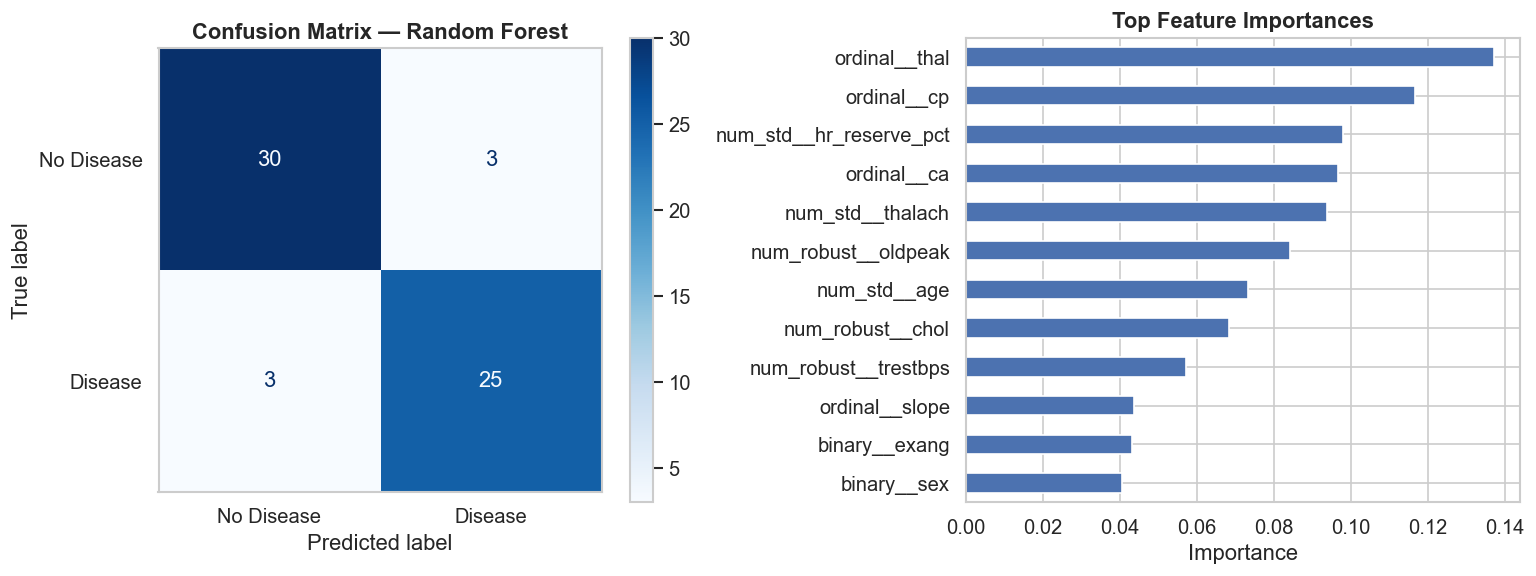

In [19]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix — Random Forest')
axes[0].grid(False)

# Feature importances
feat_names = preprocessor.get_feature_names_out()
importances = full_pipeline.named_steps['classifier'].feature_importances_
fi = pd.Series(importances, index=feat_names).sort_values(ascending=True).tail(12)
fi.plot(kind='barh', ax=axes[1], color=BLUE, edgecolor='white')
axes[1].set_title('Top Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


> **Model Results:**
> - The pipeline achieves solid AUROC right out of the box without any hyperparameter tuning.
> - **thalach** (max heart rate), **ca** (vessels), and **oldpeak** (ST depression) consistently rank as the most important features — perfectly aligned with clinical cardiology literature.
> - The pipeline structure makes swapping classifiers trivial — just replace the final step.

**11. Summary**

**Key Findings: -**
| Finding | Detail |
|---|---|
| **Dataset** | 303 patients, 13 features, no missing values |
| **Class Balance** | 54.5% no-disease / 45.5% disease — close enough to balance |
| **Strongest Predictors** | `thalach`, `ca`, `oldpeak`, `exang`, `thal` |
| **Weak Predictors** | `fbs`, `chol` (in this cohort) |
| **Outliers** | Present in `chol` and `trestbps` — handled via RobustScaler |
| **Pipeline** | Modular, no-leakage, production-ready |